In [1]:
import copy
import torch
import torch.nn.functional as F
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import add_self_loops
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.model_selection import train_test_split

import os
import sys
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from utils.graph_utils import load_graph, save_graph
from data_processing.network_generator import PatientNetworkGenerator, build_knn_graph_with_masks

from train_hybridkg import (compute_link_loss, 
                            split_edges,
                            evaluate,
                            evaluate_link,
                            train_one_epoch,
                            train,
                            test,
                            build_x_dict
                            )

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Generate Disease-Sample-Healthy network
+ only map training data to two KGs

In [2]:
exp_path = "../AD/data/ADNI/adni_exp_2cls.csv"
scoring_path = "../AD/data/ADNI/map_ad_kg/sample_scoring_ecdf.csv"
# 1. Load expression df, smaple scoring df, KG
exp_df = pd.read_csv(exp_path, index_col=0)
if exp_df.shape[0] > exp_df.shape[1]:
    exp_df = exp_df.transpose()
data = pd.read_csv(scoring_path, index_col=0)


# clean exp_df before K-NN
# drop genes with no variation
exp_df = exp_df.loc[:, exp_df.std() > 0]
# Using median is usually safer for gene expression
exp_df = exp_df.fillna(exp_df.median())
# normalize safely
min_val = exp_df.min()
max_val = exp_df.max()
exp_norm = (exp_df - min_val) / (max_val - min_val + 1e-9)
# final fill-na
exp_norm = exp_norm.fillna(0)

In [3]:
data

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,label
116_S_1249,0,0,0,0,0,-1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
037_S_4410,0,-1,0,0,-1,0,-1,0,0,0,...,1,0,1,0,0,0,-1,0,1,0
006_S_4153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
116_S_1232,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
128_S_0205,0,0,0,0,0,0,-1,0,0,0,...,0,0,0,0,0,0,-1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
014_S_4668,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
130_S_0289,0,0,0,-1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
009_S_2381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
041_S_4014,0,0,0,0,1,0,0,0,0,0,...,0,0,0,-1,0,-1,0,0,-1,0


In [4]:
exp_norm

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
116_S_1249,0.564207,0.316354,0.140463,0.642187,0.505872,0.053838,0.505814,0.599464,0.546019,0.162913,...,0.873684,0.424667,0.190404,0.683531,0.627700,0.133333,0.360470,0.491856,0.735520,0.779925
037_S_4410,0.292272,0.097185,0.341580,0.437500,0.144535,0.162848,0.000000,0.454692,0.511634,0.249249,...,0.977117,0.638800,0.326288,0.816074,0.554559,0.151782,0.417578,0.076999,0.356595,0.896745
006_S_4153,0.347472,0.407507,0.335595,0.384375,0.334237,0.245384,0.156977,0.528150,0.441830,0.416667,...,0.585812,0.500000,0.386512,0.586825,0.570945,0.407547,0.611989,0.437315,0.760293,0.614615
116_S_1232,0.401511,0.431635,0.458101,0.353125,0.313460,0.290768,0.750000,0.688472,0.483971,0.430931,...,0.487414,0.406800,0.326959,0.444532,0.605456,0.259119,0.478331,0.542201,0.643057,0.435741
128_S_0205,0.298664,0.409517,0.183160,0.303906,0.406504,0.292770,0.047965,0.618767,0.334798,0.347598,...,0.792677,0.587333,0.326791,0.694335,0.688667,0.138365,0.557918,0.153998,0.467900,0.744829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
014_S_4668,0.377687,0.310322,0.323224,0.575000,0.841915,0.428031,0.617733,0.549598,0.568769,0.704204,...,0.215103,0.335867,0.247777,0.328327,0.462193,0.365199,0.436412,0.537019,0.362177,0.540861
130_S_0289,0.399768,0.327748,0.175978,0.057031,0.360434,0.231146,0.319767,0.510992,0.330403,0.372372,...,0.828375,0.474400,0.405133,0.928854,0.568198,0.238574,0.396922,0.480750,0.648988,0.712784
009_S_2381,0.361418,0.612601,0.333998,0.506250,0.589883,0.507453,0.517442,0.471850,0.320579,0.499249,...,0.313043,0.280667,0.335346,0.374704,0.547968,0.156394,0.461928,0.526900,0.318562,0.455239
041_S_4014,0.495061,0.541555,0.367917,0.657812,0.775068,0.443826,0.422965,0.714209,0.344105,0.384384,...,0.090618,0.378667,0.194263,0.385771,0.305291,0.219706,0.149656,0.670533,0.306699,0.141404


In [7]:
for edge in G_sample.edges(data=True, keys=True):
    print(edge)
    break

for node in G_sample.nodes(data=True):
    print(node)
    break

('116_S_1249', '021_S_4335', 0, {'relation': 'similar', 'weight': 0.9352798343472625})
('116_S_1249', {'x': array([0.56420686, 0.31635389, 0.14046289, ..., 0.49185587, 0.73551989,
       0.7799254 ]), 'y': 1, 'train_mask': False, 'val_mask': False, 'test_mask': True, 'type': 'Patient'})


In [8]:
G_sample.nodes['116_S_1249']['train_mask']

False

In [3]:
kg_disease_path = "../AD/data/KG/ad_kg_reversed_noncausal_removed.pkl"
kg_health_path = "../AD/data/KG/healthy_aging_reversed_remove_noncausal.pkl"
kg_disease = load_graph(kg_disease_path)
kg_control = load_graph(kg_health_path)

pattern_disease =  r'^p\(HGNC:"([^"]+)"\)$'
pattern_control =  r'^p\(UniProtKB:"([^"_%]+)_[A-Z]+"\)$'

png = PatientNetworkGenerator(kg_disease=kg_disease,
                                  kg_healthy=kg_control)

network, summary, radicals = png.generate_hybrid_network(data=data,
                                exp_df=exp_norm,
                                pattern_disease=pattern_disease,
                                pattern_control=pattern_control,
                                disease_label=1,
                                control_label=0
                                )

Loaded graph from ../AD/data/KG/ad_kg_reversed_noncausal_removed.pkl: 3732 nodes, 10554 edges
Loaded graph from ../AD/data/KG/healthy_aging_reversed_remove_noncausal.pkl: 4161 nodes, 13775 edges
Contructing Patient-Patient Netwrok


Rewiring: 100%|██████████| 455/455 [00:00<00:00, 1033.81it/s]


Rewired 0 edges.


Linking Samples to KGs: 100%|██████████| 38749/38749 [00:01<00:00, 19870.31it/s]


In [4]:
#summary.to_csv('summary_df.csv')
summary

,pos_edges,neg_edges,train,val,test,linked_nodes,label
116_S_1249,25,43,True,False,False,"[p(HGNC:""ABCA1""), p(HGNC:""ACE""), p(HGNC:""AGTR1...",1
037_S_4410,14,49,True,False,False,"[p(UniProtKB:""ABCA7_HUMAN""), p(UniProtKB:""ABCG...",0
006_S_4153,29,16,True,False,False,"[p(HGNC:""AGTR1""), p(HGNC:""AKAP13""), p(HGNC:""AP...",1
116_S_1232,0,0,False,True,False,[],0
128_S_0205,12,19,True,False,False,"[p(UniProtKB:""APOA2_MOUSE""), p(UniProtKB:""BACE...",0
...,...,...,...,...,...,...,...
014_S_4668,0,0,False,True,False,[],1
130_S_0289,0,0,False,False,True,[],1
009_S_2381,50,15,True,False,False,"[p(HGNC:""ABCC8""), p(HGNC:""ALB""), p(HGNC:""APOA2...",1
041_S_4014,0,0,False,False,True,[],0


In [5]:
radicals

116_S_1249  ABCA1       1
            ACE        -1
            AGTR1       1
            APOA2      -1
            APOB       -1
                       ..
007_S_0101  TNFRSF1A    1
            TNFSF10     1
            TRPV1      -1
            VAMP3       1
            YKT6        1
Length: 38749, dtype: int64

#### Get candidate protein ids for validation / test data

In [39]:
from typing import Tuple
import re
from tqdm import tqdm

class PatientNetworkGenerator:
    def __init__(self, kg_disease, kg_healthy):
        """
        Initializes with knowledge graphs. All input graphs are forced to MultiDiGraph.
        """
        # Ensure all base KGs are MultiDiGraph to support multiple relations
        self.kg_disease = nx.MultiDiGraph(kg_disease)
        self.kg_healthy = nx.MultiDiGraph(kg_healthy)
        
        self.relation_map = {1: 'up_reg', -1: 'down_reg'}

    def gene_symbol_extractor(self, text, pattern:str):
        # ^ ensures start at the beginning, $ ensures end at the ')'
        match = re.search(pattern, text)
        if match:
            target = match.group(1)
            return target.upper()
        return None

    def get_symbol_mapping(self, graph: nx.Graph, pattern: str):
        """Helper function to create {gene_symbol: kg_node} mapping"""
        mapping = {}
        if graph is None: return mapping
        for node in graph.nodes:
            symbol = self.gene_symbol_extractor(node, pattern)
            if symbol:
                mapping[symbol] = node
        return mapping

    def generate_hybrid_network(
                                self, 
                                data: pd.DataFrame, 
                                exp_df: pd.DataFrame, 
                                pattern_disease: str,
                                pattern_control:str,
                                disease_label: int = 1,
                                control_label: int = 0
                            ) -> Tuple[nx.Graph, pd.DataFrame, pd.Series]:
        """
        Generates a combined network:
        1. Patient-Patient network via K-NN clustering based on Cosine Similarity.
        2. Disease Patients -> KG_Disease.
        3. Control Patients -> KG_Control.
        """
        # 1. Setup and Mappings
        patient_labels = data['label'].to_dict()
        scores = data.drop(columns=['label'])
        
        map_disease = self.get_symbol_mapping(self.kg_disease, pattern_disease)
        map_control = self.get_symbol_mapping(self.kg_healthy, pattern_control)

        # Initialize the big network with both KGs combined
        # nx.compose merges nodes and edges from both graphs
        full_graph = nx.compose(self.kg_disease, self.kg_healthy)
        
        # 2. Add Patient-Patient Similarity Edges (Cosine)
        print("Contructing Patient-Patient Netwrok")
        patient_graph = build_knn_graph_with_masks(features_df=exp_df,
                                                   labels_series=data['label'],
                                                   k=5,
                                                   base_graph_type=type(full_graph))
        full_graph = nx.compose(full_graph, patient_graph)
        
        # 3. Add Patient-Protein Edges based on Label
        # Initialize summary_df
        summary_df = pd.DataFrame(0, index=data.index, columns=['pos_edges', 'neg_edges'])

        # Explicitly add the mask columns as boolean/object types
        summary_df['train'] = False
        summary_df['val'] = False
        summary_df['test'] = False
        summary_df['linked_nodes'] = [[] for _ in range(len(summary_df))] # Initialize with empty lists
        summary_df['label'] = data['label'].to_list()
        # Pre-fill the masks for all patients from the patient_graph
        for patient in summary_df.index:
            node_attrs = patient_graph.nodes[patient]
            summary_df.at[patient, 'train'] = node_attrs.get('train_mask', False)
            summary_df.at[patient, 'val'] = node_attrs.get('val_mask', False)
            summary_df.at[patient, 'test'] = node_attrs.get('test_mask', False)
            # Initialize an empty list for each patient to store linked symbols/nodes
            summary_df.at[patient, 'linked_nodes'] = []
        
        # Identify radicals to iterate over
        all_common = set(map_disease.keys()) | set(map_control.keys()) # find union gene symbols in both KGs
        common_cols = [c for c in scores.columns if c in all_common and c in exp_df.columns] # find intersection gene symbols in expression data
        radicals = scores[common_cols].stack()
        radicals = radicals[radicals != 0]
        
        for (patient, symbol), val in tqdm(radicals.items(), total=len(radicals), desc="Linking Samples to KGs"):
            label = patient_labels[patient]
            # check if patient is training sample
            is_train = patient_graph.nodes[patient].get('train_mask', False)
            
            if is_train:
                if label == disease_label and symbol in map_disease:
                    target_node = map_disease[symbol]
                elif label == control_label and symbol in map_control:
                    target_node = map_control[symbol]
                else:
                    continue 

                rel = self.relation_map.get(int(val))
                weight = float(exp_df.loc[patient, symbol])

                full_graph.add_edge(patient, target_node, relation=rel, weight=weight)
                full_graph.add_edge(target_node, patient, relation=f'rev_{rel}', weight=weight)
                
                # Update summary_df
                col = 'pos_edges' if int(val) == 1 else 'neg_edges'
                summary_df.at[patient, col] += 1
                
                # Append the target node name to the list of linked nodes
                summary_df.at[patient, 'linked_nodes'].append(target_node)
            else:
                # Optional: Handle non-training nodes if necessary
                pass

        return full_graph, summary_df, radicals
    
    def get_candidate_node_names(self, summary_df, radicals, pattern_disease, pattern_control, split='val'):
        """
        Returns dictionaries mapping patient_name to lists of protein_node_names.
        """
        val_sample_names = summary_df[summary_df[split] == True].index.to_list()
        
        map_disease = self.get_symbol_mapping(self.kg_disease, pattern_disease)
        map_control = self.get_symbol_mapping(self.kg_healthy, pattern_control)

        # Result structure: { patient_name: [node_name1, node_name2, ...] }
        d_up, d_down, c_up, c_down = {}, {}, {}, {}

        for name in val_sample_names:
            d_up[name], d_down[name], c_up[name], c_down[name] = [], [], [], []
            sample_radicals = radicals[name] # All genes for this sample
            
            for symbol, direction in sample_radicals.items():
                # Check Disease KG
                if symbol in map_disease:
                    node_name = map_disease[symbol]
                    if direction == 1: d_up[name].append(node_name)
                    else: d_down[name].append(node_name)
                
                # Check Control KG
                if symbol in map_control:
                    node_name = map_control[symbol]
                    if direction == 1: c_up[name].append(node_name)
                    else: c_down[name].append(node_name)

        return val_sample_names, d_up, d_down, c_up, c_down
        

In [ ]:
png = PatientNetworkGenerator(kg_disease=kg_disease,
                                  kg_healthy=kg_control)

network, summary, radicals = png.generate_hybrid_network(data=data,
                                exp_df=exp_norm,
                                pattern_disease=pattern_disease,
                                pattern_control=pattern_control,
                                disease_label=1,
                                control_label=0
                                )

In [41]:
val_samples, d_up_nodes, d_down_nodes, c_up_nodes, c_down_nodes = png.get_candidate_node_names(summary, radicals, pattern_disease, pattern_control)

## Prepare HeteroData

In [51]:
from utilities import convert_to_hetero_data, bridge_names_to_indices

In [48]:
Data, node_mappings = convert_to_hetero_data(network)

Starting conversion from NetworkX to HeteroData...
HeteroData created: 25 node types, 816 edge types.


In [54]:
Data

HeteroData(
  Patient={
    x=[455, 19100],
    y=[455],
    train_mask=[455],
    val_mask=[455],
    test_mask=[455],
  },
  Gene={
    num_nodes=808,
    x=[808, 19100],
  },
  Abundance={
    num_nodes=740,
    x=[740, 19100],
  },
  BiologicalProcess={
    num_nodes=811,
    x=[811, 19100],
  },
  Activity={
    num_nodes=763,
    x=[763, 19100],
  },
  Pathology={
    num_nodes=126,
    x=[126, 19100],
  },
  MicroRna={
    num_nodes=46,
    x=[46, 19100],
  },
  Protein={
    num_nodes=2245,
    x=[2245, 19100],
  },
  Rna={
    num_nodes=768,
    x=[768, 19100],
  },
  Translocation={
    num_nodes=171,
    x=[171, 19100],
  },
  Reaction={
    num_nodes=17,
    x=[17, 19100],
  },
  Degradation={
    num_nodes=79,
    x=[79, 19100],
  },
  CellSecretion={
    num_nodes=72,
    x=[72, 19100],
  },
  CellSurfaceExpression={
    num_nodes=25,
    x=[25, 19100],
  },
  Complex={
    num_nodes=672,
    x=[672, 19100],
  },
  Composite={
    num_nodes=210,
    x=[210, 19100],
  },
 

In [49]:
node_mappings

{'Gene': {'g(HGNC:"BDNF")': 0,
  'g(HGNC:"TP53")': 1,
  'g(HGNC:"PPP1CC")': 2,
  'g(HGNC:"VLDLR")': 3,
  'g(HGNC:"SLC1A2")': 4,
  'g(HGNC:"PTK2B")': 5,
  'g(HGNC:"PPARG")': 6,
  'g(HGNC:"LRP8")': 7,
  'g(HGNC:"SIRT1")': 8,
  'g(HGNC:"IGF1")': 9,
  'g(HGNC:"SYN2")': 10,
  'g(HGNC:"APP")': 11,
  'g(HGNC:"NFKB1")': 12,
  'g(HGNC:"CETP")': 13,
  'g(HGNC:"CREB1")': 14,
  'g(HGNC:"DNMT1")': 15,
  'g(HGNC:"NOS2")': 16,
  'g(HGNC:"INSR")': 17,
  'g(HGNC:"BACE1")': 18,
  'g(HGNC:"GFAP")': 19,
  'g(HGNC:"FOS")': 20,
  'g(HGNC:"TNF")': 21,
  'g(HGNC:"DNM2")': 22,
  'g(HGNC:"CLTC")': 23,
  'g(HGNC:"NOS3")': 24,
  'g(HGNC:"HDAC6")': 25,
  'g(HGNC:"RELA")': 26,
  'g(HGNC:"MAPT")': 27,
  'g(HGNC:"MTHFR")': 28,
  'g(HGNC:"NR1H3")': 29,
  'g(HGNC:"APOE")': 30,
  'g(HGNC:"CR1")': 31,
  'g(HGNC:"CX3CR1")': 32,
  'g(HGNC:"ENO1")': 33,
  'g(HGNC:"CTSD")': 34,
  'g(HGNC:"APP",var("G,275341,C"))': 35,
  'g(HGNC:"APP",var("G,717,C"))': 36,
  'g(HGNC:"PSEN1",var("?"))': 37,
  'g(HGNC:"TNF",var("G,308,A"))': 38

In [53]:
val_indices, d_up_ids, d_down_ids, c_up_ids, c_down_ids = bridge_names_to_indices(val_samples, 
                      d_up_nodes, 
                      d_down_nodes, 
                      c_up_nodes, 
                      c_down_nodes,
                      node_mappings)

## Train

In [67]:
from train_hybridkg import (compute_link_loss, 
                            split_edges,
                            evaluate,
                            evaluate_link,
                            train_one_epoch,
                            train,
                            test,
                            build_x_dict,
                            set_seed
                            )
from utilities import (assign_kg_by_NodeCls, 
                       assign_kg_by_EmbDistance,
                       assign_kg_by_EdgeScore,
                       add_val_kg_edges,
                       convert_to_hetero_data, 
                       bridge_names_to_indices)
from hetero_models.hetero_base_models import get_model
import argparse

In [ ]:
from train_hybridkg import (compute_link_loss, 
                            split_edges,
                            evaluate,
                            evaluate_link,
                            train_one_epoch,
                            train,
                            test,
                            build_x_dict,
                            set_seed
                            )
from utilities import (assign_kg_by_NodeCls, 
                       assign_kg_by_EmbDistance,
                       assign_kg_by_EdgeScore,
                       add_val_kg_edges,
                       convert_to_hetero_data, 
                       bridge_names_to_indices)
from hetero_models.hetero_base_models import get_model
import argparse

def run_hybrid_pipeline(args, data, model, optimizer, device,
                        val_indices, d_up_ids, d_down_ids, c_up_ids, c_down_ids):
    # --- STAGE 1: Initial Training ---
    # Only Training nodes are connected to KGs initially (done in data prep)
    print("--- Stage 1: Initial Training ---")
    train_edges = {etype: data[etype].edge_index for etype in data.edge_types}
    model, _ = train(model, data, train_edges, None, optimizer, device, epochs=args.epochs)

    # --- STAGE 2: Inference & Assignment ---
    print("--- Stage 2: Augmenting Graph with Validation Nodes ---")
    model.eval()
    with torch.no_grad():
        x_dict = {k: v.to(device) for k, v in data.x_dict.items()}
        z_dict = model.encode(x_dict, train_edges)
        
        val_mask = data['Patient'].val_mask
        val_indices = torch.where(val_mask)[0].cpu()
        val_embs = z_dict['Patient'][val_mask]
        
        # Choose your method here: 'emb', 'edge', or 'cls'
        if args.assign_method == 'emb':
            train_mask = data['Patient'].train_mask
            assignment, confidence = assign_kg_by_EmbDistance(
                val_embs, z_dict['Patient'][train_mask], data['Patient'].y[train_mask]
            )
        elif args.assign_method == 'edge':
            # This requires a slightly updated helper to handle the model's decode logic
            assignment, confidence = assign_kg_by_EdgeScore(
                model, data, z_dict, val_indices, 
                d_up_ids, d_down_ids, c_up_ids, c_down_ids, 
                device
            )
        else: # 'cls'
            assignment, confidence = assign_kg_by_NodeCls(model, z_dict, val_mask)

        
        # Update the graph
        data = add_val_kg_edges(
            data, assignment, confidence, val_indices, 
            d_up_ids, d_down_ids, c_up_ids, c_down_ids, threshold=args.confidence
        )

    # --- STAGE 3: Retraining on Augmented Graph ---
    print("--- Stage 3: Retraining ---")
    # Refresh train_edges to include the new validation-protein connections
    augmented_edges = {etype: data[etype].edge_index for etype in data.edge_types}
    
    # We allow the model to backprop through the new structure
    model, history = train(model, data, augmented_edges, None, optimizer, device, epochs=args.epochs // 2)

    return model, history

In [72]:
config = {
'exp_path': "../AD/data/ADNI/adni_exp_2cls.csv",
'scoring_path': "../AD/data/ADNI/map_ad_kg/sample_scoring_ecdf.csv",
'kg_disease_path': "../AD/data/KG/ad_kg_reversed_noncausal_removed.pkl",
'kg_health_path': "../AD/data/KG/healthy_aging_reversed_remove_noncausal.pkl",
'output_dir': "../results/HybridHeteroKG/adni/ecdf/",
'model':'gat',
'hidden_channels': 128,
'out_channels': 64,
'num_layers': 3,
'heads': 4,
'dropout': 0.3,
'epochs': 5,
'lr': 1e-3,
'weight_decay': 1e-5,
'lambda_link': 0.7,
'val_ratio': 0.15,
'test_ratio':0.15,
'seed':42,
'device': 'cuda',
'assign_method':'cls',
'confidence': 0.6
}
# convert config to Namespace
args = argparse.Namespace(**config)

In [95]:
# main() script

print("\nStart Loading Required Data...\n")
# Load expression df, smaple scoring df, KG
exp_df = pd.read_csv(args.exp_path, index_col=0)
if exp_df.shape[0] > exp_df.shape[1]:
    exp_df = exp_df.transpose()
scoring_df = pd.read_csv(args.scoring_path, index_col=0)
# clean exp_df before K-NN
# drop genes with no variation
exp_df = exp_df.loc[:, exp_df.std() > 0]
# Using median is usually safer for gene expression
exp_df = exp_df.fillna(exp_df.median())
# normalize safely
min_val = exp_df.min()
max_val = exp_df.max()
exp_norm = (exp_df - min_val) / (max_val - min_val + 1e-9)
# final fill-na
exp_norm = exp_norm.fillna(0)
# load kgs
kg_disease = load_graph(args.kg_disease_path)
kg_control = load_graph(args.kg_health_path)

pattern_disease =  r'^p\(HGNC:"([^"]+)"\)$'
pattern_control =  r'^p\(UniProtKB:"([^"_%]+)_[A-Z]+"\)$'

# 1. Generate NetworkX Graph
print("\nStart Generating Disease-Sample-Healthy Network...\n")
png = PatientNetworkGenerator(kg_disease, kg_control)
full_graph, summary_df, radicals = png.generate_hybrid_network(
                                data=scoring_df,
                                exp_df=exp_norm,
                                pattern_disease=pattern_disease,
                                pattern_control=pattern_control,
                                disease_label=1,
                                control_label=0
                                )

# 2. Get biological mappings (Names)
val_names, d_up_names, d_down_names, c_up_names, c_down_names = png.get_candidate_node_names(
                                                            summary_df, 
                                                            radicals, 
                                                            pattern_disease, 
                                                            pattern_control)

# 3. Convert to PyG (This creates the node_mappings)
print("\nStart Converting to HeteroData...\n")
data, node_mappings = convert_to_hetero_data(full_graph)

# 4. Bridge to Indices
val_indices, d_up_ids, d_down_ids, c_up_ids, c_down_ids = bridge_names_to_indices(
    val_names, d_up_names, d_down_names, c_up_names, c_down_names, node_mappings
)
# 5. Training Pipline
print("\nPrepare for training...\n")
# Setup
set_seed(args.seed)
device = torch.device(args.device if torch.cuda.is_available() else "cpu")

# Build features
data.x_dict = build_x_dict(data)

# (2) Edge split
edge_index_dict = {
    etype: data[etype].edge_index
    for etype in data.edge_types
}
train_edges, val_edges, test_edges = split_edges(
    edge_index_dict,
    val_ratio=args.val_ratio,
    test_ratio=args.test_ratio,
    seed=args.seed
)
# Labels
y = data["Patient"].y
num_classes = int(y.max().item() + 1) if y.dim() == 1 else y.size(-1)
print(f"Number of classes: {num_classes}")

# (3) Build model
print("\nStart building model...\n")
model = get_model(
    data=data,
    model_type=args.model,
    hidden_channels=args.hidden_channels,
    out_channels=args.out_channels,
    num_layers=args.num_layers,
    heads=args.heads,
    dropout=args.dropout,
    num_classes=num_classes,
    device=device
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=args.lr,
    weight_decay=args.weight_decay
)
# (4) Train
print("\nStart training...\n")
model, train_history = run_hybrid_pipeline(args, data, model, optimizer, device,
                        val_indices, d_up_ids, d_down_ids, c_up_ids, c_down_ids)

# 4. Test
print("\nTesting...\n")

test_cls_metrics, test_link_metrics = test(
    model,
    data,
    train_edges=train_edges,
    test_edges=test_edges,
    device=device
)


Start Loading Required Data...



KeyboardInterrupt: 

In [94]:
# 4. Test
print("\nTesting...\n")

test_cls_metrics, test_link_metrics = test(
    model,
    data,
    train_edges=train_edges,
    test_edges=test_edges,
    device=device
)


Testing...

Test Classification: {'acc': 0.5072463768115942, 'f1_macro': 0.3611111111111111, 'auroc': 0.7142857142857143, 'auprc': 0.7416439501691329}
Test Link: 0.23038773669972948


In [103]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Find all summary files across all experiments
files = glob.glob("../results/HybridPipeline/*/*/*/*/summary.csv")
all_results = pd.concat([pd.read_csv(f) for f in files])

In [98]:
all_results

,dataset,scoring,model,assign_method,threshold,acc,f1_macro,auroc,auprc
0,geo,ecdf,gat,cls,0.6,0.338028,0.252632,0.554078,0.645655
0,geo,ecdf,gat,edge,0.6,0.323944,0.244681,0.726950,0.834611
0,geo,ecdf,gat,emb,0.6,0.338028,0.252632,0.940603,0.972807
0,adni,ecdf,gat,cls,0.6,0.507246,0.498718,0.499160,0.514647
0,adni,ecdf,gat,edge,0.6,0.507246,0.507143,0.506723,0.576968
0,adni,ecdf,gat,emb,0.6,0.507246,0.336538,0.672269,0.640224


<Axes: xlabel='model', ylabel='acc'>

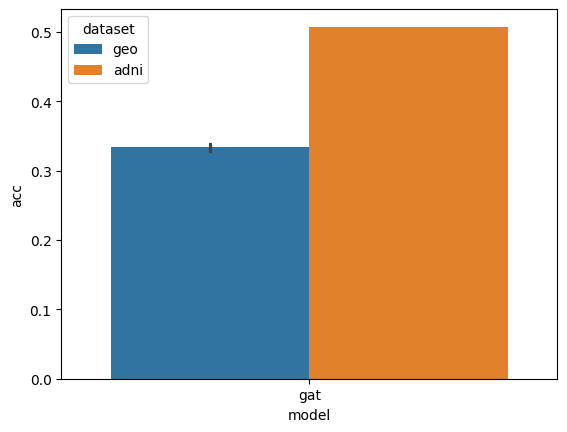

In [100]:

sns.barplot(data=all_results, x="model", y="acc", hue="dataset")

In [101]:
df_melted = all_results.melt(
    id_vars=['dataset', 'assign_method'], 
    value_vars=['acc', 'f1_macro', 'auroc', 'auprc'],
    var_name='Metric', 
    value_name='Score'
)
df_melted

,dataset,assign_method,Metric,Score
0,geo,cls,acc,0.338028
1,geo,edge,acc,0.323944
2,geo,emb,acc,0.338028
3,adni,cls,acc,0.507246
4,adni,edge,acc,0.507246
5,adni,emb,acc,0.507246
6,geo,cls,f1_macro,0.252632
7,geo,edge,f1_macro,0.244681
8,geo,emb,f1_macro,0.252632
9,adni,cls,f1_macro,0.498718


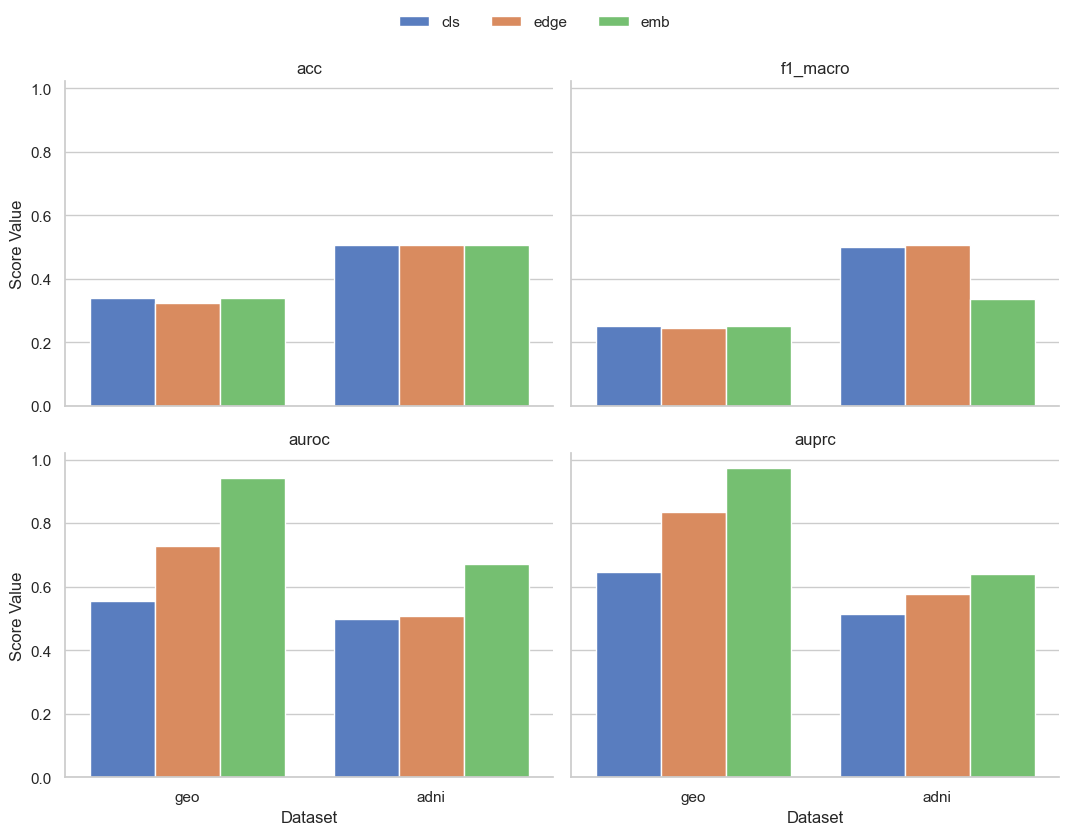

In [109]:
# plot
sns.set_theme(style="whitegrid")

# use catplot to create a "FacetGrid" (separate plots for each metric)
g = sns.catplot(
    data=df_melted, 
    kind="bar",
    x="dataset", 
    y="Score", 
    hue="assign_method",
    col="Metric", 
    col_wrap=2,  # Arranges plots in a 2x2 grid
    palette="muted", 
    height=4, 
    aspect=1.2
)

g.set_axis_labels("Dataset", "Score Value")
g.set_titles("{col_name}")  # Titles for each subplot (acc, auroc, etc.)
#g.add_legend(title="Assignment Method")
sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300)
plt.show()